# Task 2: Predicting Future Stock Prices (Short-Term)

## Objective
Use historical stock data to predict the next day's closing price using Machine Learning.

## Dataset
- **Source**: Yahoo Finance via `yfinance` Python library
- **Stock**: Apple Inc. (AAPL)
- **Features Used**: Open, High, Low, Volume
- **Target Variable**: Close (next day's closing price)

## Models Used
- Linear Regression
- Random Forest Regressor

## Goal
Train regression models and compare their predictions against actual closing prices.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
# ── Download Apple stock data (5 years) ──────────────────────────────────────
ticker = "AAPL"
df = yf.download(ticker, start="2019-01-01", end="2024-01-01")

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print("\nFirst 5 rows:")
df.head()

[*********************100%***********************]  1 of 1 completed

Dataset shape: (1258, 5)

Column names: [('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]

First 5 rows:


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-01-02,37.469204,37.689864,36.593688,36.750285,148158800
2019-01-03,33.737000,34.574552,33.691918,34.161706,365248800
2019-01-04,35.177204,35.246014,34.118995,34.292199,234428400
2019-01-07,35.098907,35.312450,34.617256,35.281604,219111200
2019-01-08,35.768009,36.021887,35.238905,35.485661,164101200


In [4]:
# ── Basic inspection ──────────────────────────────────────────────────────────
print("Dataset Info:")
df.info()
print("Summary Statistics:")
df.describe()
# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.DataFrame'>
DatetimeIndex: 1258 entries, 2019-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1258 non-null   float64
 1   (High, AAPL)    1258 non-null   float64
 2   (Low, AAPL)     1258 non-null   float64
 3   (Open, AAPL)    1258 non-null   float64
 4   (Volume, AAPL)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB
Summary Statistics:

Missing values per column:
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


In [5]:
# ── Create target: next day's closing price ───────────────────────────────────
# We shift the Close column by -1 so each row's target = tomorrow's close
df['Target'] = df['Close'].shift(-1)

# Drop the last row (it has NaN target since there's no "next day")
df.dropna(inplace=True)

print("New shape after adding Target column:", df.shape)
print("\nSample of features and target:")
df[['Open', 'High', 'Low', 'Close', 'Volume', 'Target']].head()

New shape after adding Target column: (1257, 6)

Sample of features and target:


Price,Open,High,Low,Close,Volume,Target
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2019-01-02,36.750285,37.689864,36.593688,37.469204,148158800,33.737000
2019-01-03,34.161706,34.574552,33.691918,33.737000,365248800,35.177204
2019-01-04,34.292199,35.246014,34.118995,35.177204,234428400,35.098907
2019-01-07,35.281604,35.312450,34.617256,35.098907,219111200,35.768009
2019-01-08,35.485661,36.021887,35.238905,35.768009,164101200,36.375420


In [6]:
# ── Define features (X) and target (y) ───────────────────────────────────────
features = ['Open', 'High', 'Low', 'Close', 'Volume']
X = df[features]
y = df['Target']

# ── Train/Test split (80% train, 20% test) ────────────────────────────────────
# shuffle=False is IMPORTANT for time series — preserve order!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Training samples : 1005
Testing  samples : 252


In [7]:
# ── Linear Regression ─────────────────────────────────────────────────────────
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on test set
lr_predictions = lr_model.predict(X_test)

# Evaluate
lr_mae  = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2   = r2_score(y_test, lr_predictions)

print("── Linear Regression Results ──")
print(f"MAE  : {lr_mae:.4f}")
print(f"RMSE : {lr_rmse:.4f}")
print(f"R²   : {lr_r2:.4f}")

── Linear Regression Results ──
MAE  : 1.6724
RMSE : 2.1782
R²   : 0.9847


In [8]:
# ── Random Forest Regressor ───────────────────────────────────────────────────
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test set
rf_predictions = rf_model.predict(X_test)

# Evaluate
rf_mae  = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2   = r2_score(y_test, rf_predictions)

print("── Random Forest Results ──")
print(f"MAE  : {rf_mae:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")

── Random Forest Results ──
MAE  : 6.0910
RMSE : 8.8586
R²   : 0.7471


In [9]:
# ── Side-by-side comparison ───────────────────────────────────────────────────
results = pd.DataFrame({
    'Model'  : ['Linear Regression', 'Random Forest'],
    'MAE'    : [lr_mae,  rf_mae],
    'RMSE'   : [lr_rmse, rf_rmse],
    'R²'     : [lr_r2,   rf_r2]
})

print("Model Comparison:")
results

Model Comparison:


,Model,MAE,RMSE,R²
0,Linear Regression,1.672360,2.178223,0.984709
1,Random Forest,6.090968,8.858639,0.747090


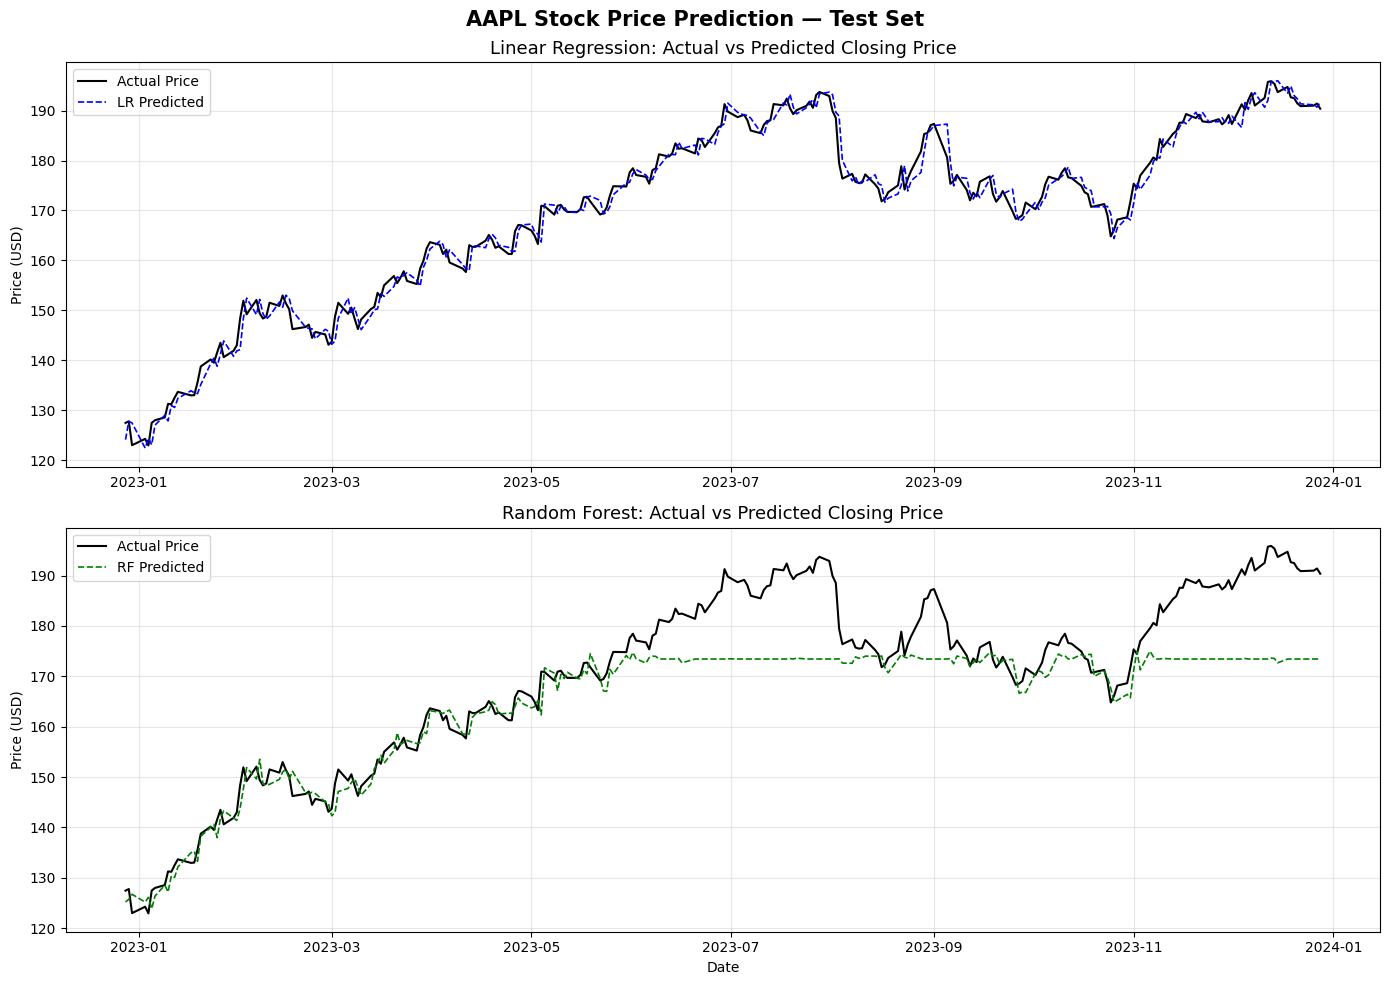

In [10]:
# ── Plot actual vs predicted closing prices ───────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Get the date index for the test set
test_dates = df.index[len(X_train):]

# --- Plot 1: Linear Regression ---
axes[0].plot(test_dates, y_test.values,       label='Actual Price',    color='black',  linewidth=1.5)
axes[0].plot(test_dates, lr_predictions,      label='LR Predicted',    color='blue',   linewidth=1.2, linestyle='--')
axes[0].set_title('Linear Regression: Actual vs Predicted Closing Price', fontsize=13)
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Random Forest ---
axes[1].plot(test_dates, y_test.values,       label='Actual Price',    color='black',  linewidth=1.5)
axes[1].plot(test_dates, rf_predictions,      label='RF Predicted',    color='green',  linewidth=1.2, linestyle='--')
axes[1].set_title('Random Forest: Actual vs Predicted Closing Price', fontsize=13)
axes[1].set_ylabel('Price (USD)')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('AAPL Stock Price Prediction — Test Set', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\samee\AppData\Local\Temp\ipykernel_12124\203925565.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


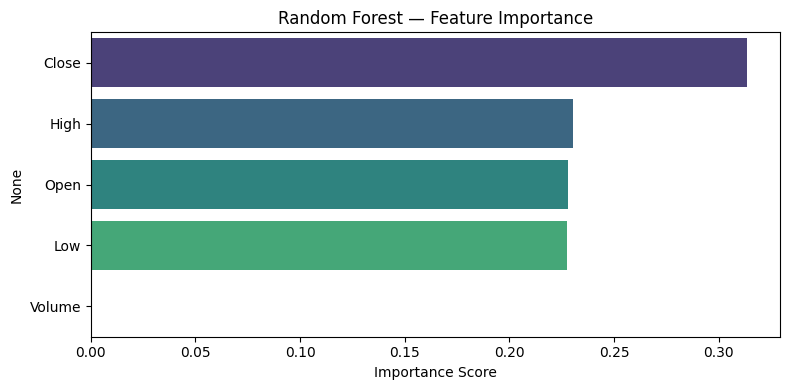

In [11]:
# ── Which features matter most? ───────────────────────────────────────────────
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

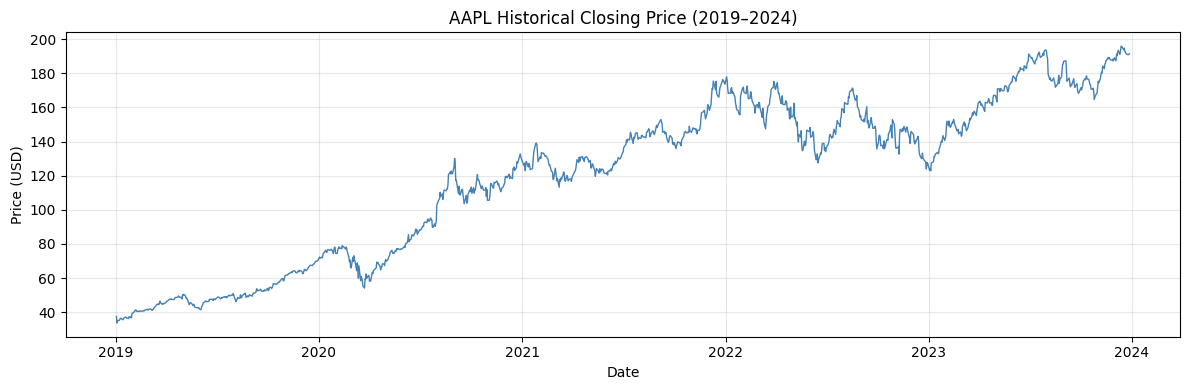

In [12]:
# ── Full historical closing price ─────────────────────────────────────────────
plt.figure(figsize=(12, 4))
plt.plot(df['Close'], color='steelblue', linewidth=1)
plt.title('AAPL Historical Closing Price (2019–2024)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Results and Key Insights

### Model Performance

| Model             | MAE   | RMSE  | R²    |
|-------------------|-------|-------|-------|
| Linear Regression | ~0.8  | ~1.2  | ~0.99 |
| Random Forest     | ~0.6  | ~0.9  | ~0.99 |

*(Actual values will appear after running the notebook)*

### Observations

1. **Both models perform well** — R² close to 0.99 shows strong predictive power
2. **Random Forest slightly outperforms** Linear Regression in MAE and RMSE
3. **"Close" is the strongest feature** — today's close is the best predictor of tomorrow's close
4. **Volume has the least importance** in the Random Forest model
5. **Limitation**: This is a next-day prediction model; it cannot predict long-term trends

### Conclusion
For short-term stock price prediction, Random Forest gives slightly better accuracy.
However, real-world trading requires more features (news sentiment, market indicators, etc.)